In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [121]:
train_df = pd.read_csv("train_cleaned.csv")
test_df = pd.read_csv("test_cleaned.csv")
X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [122]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['float64','int64']).columns

In [123]:
for col in X[categorical_cols].columns:
    unique_values = X[col].unique()
    print(f"{col} - Unique values: {unique_values[:]}")

시술 시기 코드 - Unique values: ['TRZKPL' 'TRYBLT' 'TRVNRY' 'TRJXFG' 'TRXQMD' 'TRCMWS' 'TRDQAZ']
시술 당시 나이 - Unique values: ['만18-34세' '만45-50세' '만35-37세' '만38-39세' '만40-42세' '만43-44세' '알 수 없음']
시술 유형 - Unique values: ['IVF' 'DI']
특정 시술 유형 - Unique values: ['ICSI' 'IVF' 'Unknown' 'IUI' 'IVF:IVF' 'IVF / BLASTOCYST' 'ICSI:IVF'
 'ICSI / AH' 'ICSI:ICSI' 'IVF:ICSI' 'ICSI / BLASTOCYST ' 'IVF:Unknown'
 'ICSI:Unknown' 'IVF / AH' 'IVI' 'Generic DI'
 'ICSI / BLASTOCYST :IVF / BLASTOCYST' 'ICI' 'IVF / AH:ICSI / AH' 'GIFT'
 'ICSI / BLASTOCYST:IVF / BLASTOCYST' 'ICSI / AH:Unknown' 'FER'
 'ICSI / BLASTOCYST :ICSI']
배란 유도 유형 - Unique values: ['기록되지 않은 시행' '알 수 없음' '세트로타이드 (억제제)' '생식선 자극 호르몬']
배아 생성 주요 이유 - Unique values: ['현재 시술용' 'Unknown' '난자 저장용' '배아 저장용' '기증용, 현재 시술용' '기증용, 배아 저장용' '기증용'
 '기증용, 난자 저장용' '배아 저장용, 현재 시술용' '난자 저장용, 배아 저장용' '기증용, 배아 저장용, 현재 시술용'
 '연구용, 현재 시술용' '난자 저장용, 현재 시술용' '난자 저장용, 배아 저장용, 연구용']
총 시술 횟수 - Unique values: ['0회' '1회' '2회' '6회 이상' '3회' '4회' '5회']
클리닉 내 총 시술 횟수 - Unique value

#### 특정 시술 유형, 배아 생성 주요 이유 고유값 개수 줄이기
#### 인코딩 전 정렬 필요해보임

In [124]:
# 세부 사항 제거
X['특정 시술 유형'] = X['특정 시술 유형'].str.split(r"\s*[:/]\s*").str[0]
print(X['특정 시술 유형'].value_counts())
test_df['특정 시술 유형'] = test_df['특정 시술 유형'].str.split(r"\s*[:/]\s*").str[0]
print(test_df['특정 시술 유형'].value_counts())

# 빈도 낮은 유형 Other로 변경
threshold = 0.01 * len(X)
cnt_feature = X['특정 시술 유형'].value_counts()
low_freq = cnt_feature[cnt_feature < threshold].index
X['특정 시술 유형'] = X['특정 시술 유형'].apply(
    lambda x: 'Other' if x in low_freq else x
)
test_df['특정 시술 유형'] = test_df['특정 시술 유형'].apply(
    lambda x: 'Other' if x in low_freq else x
)
print(X['특정 시술 유형'].value_counts())
print(test_df['특정 시술 유형'].value_counts())

특정 시술 유형
ICSI          128153
IVF            94962
Unknown        26941
IUI             6100
ICI               96
Generic DI        71
IVI               23
FER                3
GIFT               2
Name: count, dtype: int64
특정 시술 유형
ICSI          45250
IVF           33425
Unknown        9216
IUI            2114
ICI              28
Generic DI       26
IVI               8
Name: count, dtype: int64
특정 시술 유형
ICSI       128153
IVF         94962
Unknown     26941
IUI          6100
Other         195
Name: count, dtype: int64
특정 시술 유형
ICSI       45250
IVF        33425
Unknown     9216
IUI         2114
Other         62
Name: count, dtype: int64


In [125]:
def normalize_category(value):
    return ', '.join(sorted(value.split(', ')))  # 쉼표 기준으로 정렬 후 합치기

# Train/Test 데이터에 적용
X['배아 생성 주요 이유'] = X['배아 생성 주요 이유'].apply(normalize_category)
test_df['배아 생성 주요 이유'] = test_df['배아 생성 주요 이유'].apply(normalize_category)

# 변경 후 고유값 확인
print("정리 후 Train 데이터 고유값:\n", X['배아 생성 주요 이유'].unique())
print("정리 후 Test 데이터 고유값:\n", test_df['배아 생성 주요 이유'].unique())

# 1% 미만인 값 찾기
threshold = 0.01 * len(X)  # 1% 기준 계산
cnt_values = X['배아 생성 주요 이유'].value_counts()
low_freq_values = cnt_values[cnt_values < threshold].index  # 1% 미만인 값들 찾기

# Train 데이터에서 1% 미만 값은 'Other'로 변경
X['배아 생성 주요 이유'] = X['배아 생성 주요 이유'].apply(
    lambda x: 'Other' if x in low_freq_values else x
)

# Test 데이터에서도 동일한 기준 적용
test_df['배아 생성 주요 이유'] = test_df['배아 생성 주요 이유'].apply(
    lambda x: 'Other' if x in low_freq_values else x
)

# 변경 후 값 개수 확인
print("Train 데이터 분포:\n", X['배아 생성 주요 이유'].value_counts())
print("\nTest 데이터 분포:\n", test_df['배아 생성 주요 이유'].value_counts())


정리 후 Train 데이터 고유값:
 ['현재 시술용' 'Unknown' '난자 저장용' '배아 저장용' '기증용, 현재 시술용' '기증용, 배아 저장용' '기증용'
 '기증용, 난자 저장용' '배아 저장용, 현재 시술용' '난자 저장용, 배아 저장용' '기증용, 배아 저장용, 현재 시술용'
 '연구용, 현재 시술용' '난자 저장용, 현재 시술용' '난자 저장용, 배아 저장용, 연구용']
정리 후 Test 데이터 고유값:
 ['현재 시술용' 'Unknown' '배아 저장용' '배아 저장용, 현재 시술용' '기증용, 현재 시술용' '난자 저장용' '기증용'
 '기증용, 배아 저장용' '기증용, 난자 저장용' '기증용, 배아 저장용, 현재 시술용' '난자 저장용, 현재 시술용'
 '난자 저장용, 배아 저장용']
Train 데이터 분포:
 배아 생성 주요 이유
현재 시술용         233732
배아 저장용           9192
Unknown          6291
기증용, 현재 시술용      3784
Other            3352
Name: count, dtype: int64

Test 데이터 분포:
 배아 생성 주요 이유
현재 시술용         82253
배아 저장용          3151
Unknown         2176
기증용, 현재 시술용     1327
Other           1160
Name: count, dtype: int64


In [126]:
for col in X[categorical_cols].columns:
    unique_values = X[col].unique()
    print(f"{col} - Unique values: {unique_values[:]}")

시술 시기 코드 - Unique values: ['TRZKPL' 'TRYBLT' 'TRVNRY' 'TRJXFG' 'TRXQMD' 'TRCMWS' 'TRDQAZ']
시술 당시 나이 - Unique values: ['만18-34세' '만45-50세' '만35-37세' '만38-39세' '만40-42세' '만43-44세' '알 수 없음']
시술 유형 - Unique values: ['IVF' 'DI']
특정 시술 유형 - Unique values: ['ICSI' 'IVF' 'Unknown' 'IUI' 'Other']
배란 유도 유형 - Unique values: ['기록되지 않은 시행' '알 수 없음' '세트로타이드 (억제제)' '생식선 자극 호르몬']
배아 생성 주요 이유 - Unique values: ['현재 시술용' 'Unknown' 'Other' '배아 저장용' '기증용, 현재 시술용']
총 시술 횟수 - Unique values: ['0회' '1회' '2회' '6회 이상' '3회' '4회' '5회']
클리닉 내 총 시술 횟수 - Unique values: ['0회' '1회' '2회' '6회 이상' '3회' '5회' '4회']
IVF 시술 횟수 - Unique values: ['0회' '1회' '2회' '3회' '5회' '4회' '6회 이상']
DI 시술 횟수 - Unique values: ['0회' '5회' '3회' '1회' '2회' '4회' '6회 이상']
총 임신 횟수 - Unique values: ['0회' '1회' '2회' '3회' '4회' '5회' '6회 이상']
IVF 임신 횟수 - Unique values: ['0회' '1회' '2회' '3회' '4회' '5회' '6회 이상']
DI 임신 횟수 - Unique values: ['0회' '1회' '2회' '3회' '4회' '5회']
총 출산 횟수 - Unique values: ['0회' '1회' '2회' '3회' '4회' '6회 이상' '5회']
IVF 출산 횟수 - Unique values: [

In [127]:
for col in X[numerical_cols].columns:
    unique_values = sorted(test_df[col].unique())  # 고유값 정렬
    print(f"{col} - Sorted Unique values: {unique_values}") 

배란 자극 여부 - Sorted Unique values: [0, 1]
단일 배아 이식 여부 - Sorted Unique values: [0.0, 1.0]
착상 전 유전 진단 사용 여부 - Sorted Unique values: [0.0, 1.0]
남성 주 불임 원인 - Sorted Unique values: [0, 1]
남성 부 불임 원인 - Sorted Unique values: [0, 1]
여성 주 불임 원인 - Sorted Unique values: [0, 1]
여성 부 불임 원인 - Sorted Unique values: [0, 1]
부부 주 불임 원인 - Sorted Unique values: [0, 1]
부부 부 불임 원인 - Sorted Unique values: [0, 1]
불명확 불임 원인 - Sorted Unique values: [0, 1]
불임 원인 - 난관 질환 - Sorted Unique values: [0, 1]
불임 원인 - 남성 요인 - Sorted Unique values: [0, 1]
불임 원인 - 배란 장애 - Sorted Unique values: [0, 1]
불임 원인 - 여성 요인 - Sorted Unique values: [0]
불임 원인 - 자궁경부 문제 - Sorted Unique values: [0, 1]
불임 원인 - 자궁내막증 - Sorted Unique values: [0, 1]
불임 원인 - 정자 농도 - Sorted Unique values: [0, 1]
불임 원인 - 정자 면역학적 요인 - Sorted Unique values: [0, 1]
불임 원인 - 정자 운동성 - Sorted Unique values: [0, 1]
불임 원인 - 정자 형태 - Sorted Unique values: [0, 1]
총 생성 배아 수 - Sorted Unique values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0

In [128]:
X = X.drop(columns=['불임 원인 - 여성 요인'])
test_df = test_df.drop(columns=['불임 원인 - 여성 요인'])

In [130]:
## 0이 많은 열에 대해서 이진화
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['float64','int64']).columns

features = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수", "저장된 배아 수", "미세주입 후 저장된 배아 수",
    "해동된 배아 수", "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수", "해동 난자 수"
]
binary_transformed_df = X.copy()
binary_tt_df = test_df.copy()
for feature in features:
    binary_transformed_df[feature] = (binary_transformed_df[feature] > 0).astype(int)
    binary_tt_df[feature] = (binary_tt_df[feature] > 0).astype(int)

for col in binary_transformed_df[numerical_cols].columns:
    unique_values = sorted(binary_transformed_df[col].unique())
    print(f"{col} - Sorted Unique values: {unique_values}") 


배란 자극 여부 - Sorted Unique values: [0, 1]
단일 배아 이식 여부 - Sorted Unique values: [0.0, 1.0]
착상 전 유전 진단 사용 여부 - Sorted Unique values: [0.0, 1.0]
남성 주 불임 원인 - Sorted Unique values: [0, 1]
남성 부 불임 원인 - Sorted Unique values: [0, 1]
여성 주 불임 원인 - Sorted Unique values: [0, 1]
여성 부 불임 원인 - Sorted Unique values: [0, 1]
부부 주 불임 원인 - Sorted Unique values: [0, 1]
부부 부 불임 원인 - Sorted Unique values: [0, 1]
불명확 불임 원인 - Sorted Unique values: [0, 1]
불임 원인 - 난관 질환 - Sorted Unique values: [0, 1]
불임 원인 - 남성 요인 - Sorted Unique values: [0, 1]
불임 원인 - 배란 장애 - Sorted Unique values: [0, 1]
불임 원인 - 자궁경부 문제 - Sorted Unique values: [0, 1]
불임 원인 - 자궁내막증 - Sorted Unique values: [0, 1]
불임 원인 - 정자 농도 - Sorted Unique values: [0, 1]
불임 원인 - 정자 면역학적 요인 - Sorted Unique values: [0, 1]
불임 원인 - 정자 운동성 - Sorted Unique values: [0, 1]
불임 원인 - 정자 형태 - Sorted Unique values: [0, 1]
총 생성 배아 수 - Sorted Unique values: [0, 1]
미세주입된 난자 수 - Sorted Unique values: [0, 1]
미세주입에서 생성된 배아 수 - Sorted Unique values: [0, 1]
이식된 배아 수 - Sorted Unique 

### 시각화

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16628\438989179.py:24: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16628\438989179.py:24: UserWarning: Glyph 46976 (\N{HANGUL SYLLABLE RAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16628\438989179.py:24: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16628\438989179.py:24: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_16628\438989179.py:24: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing f

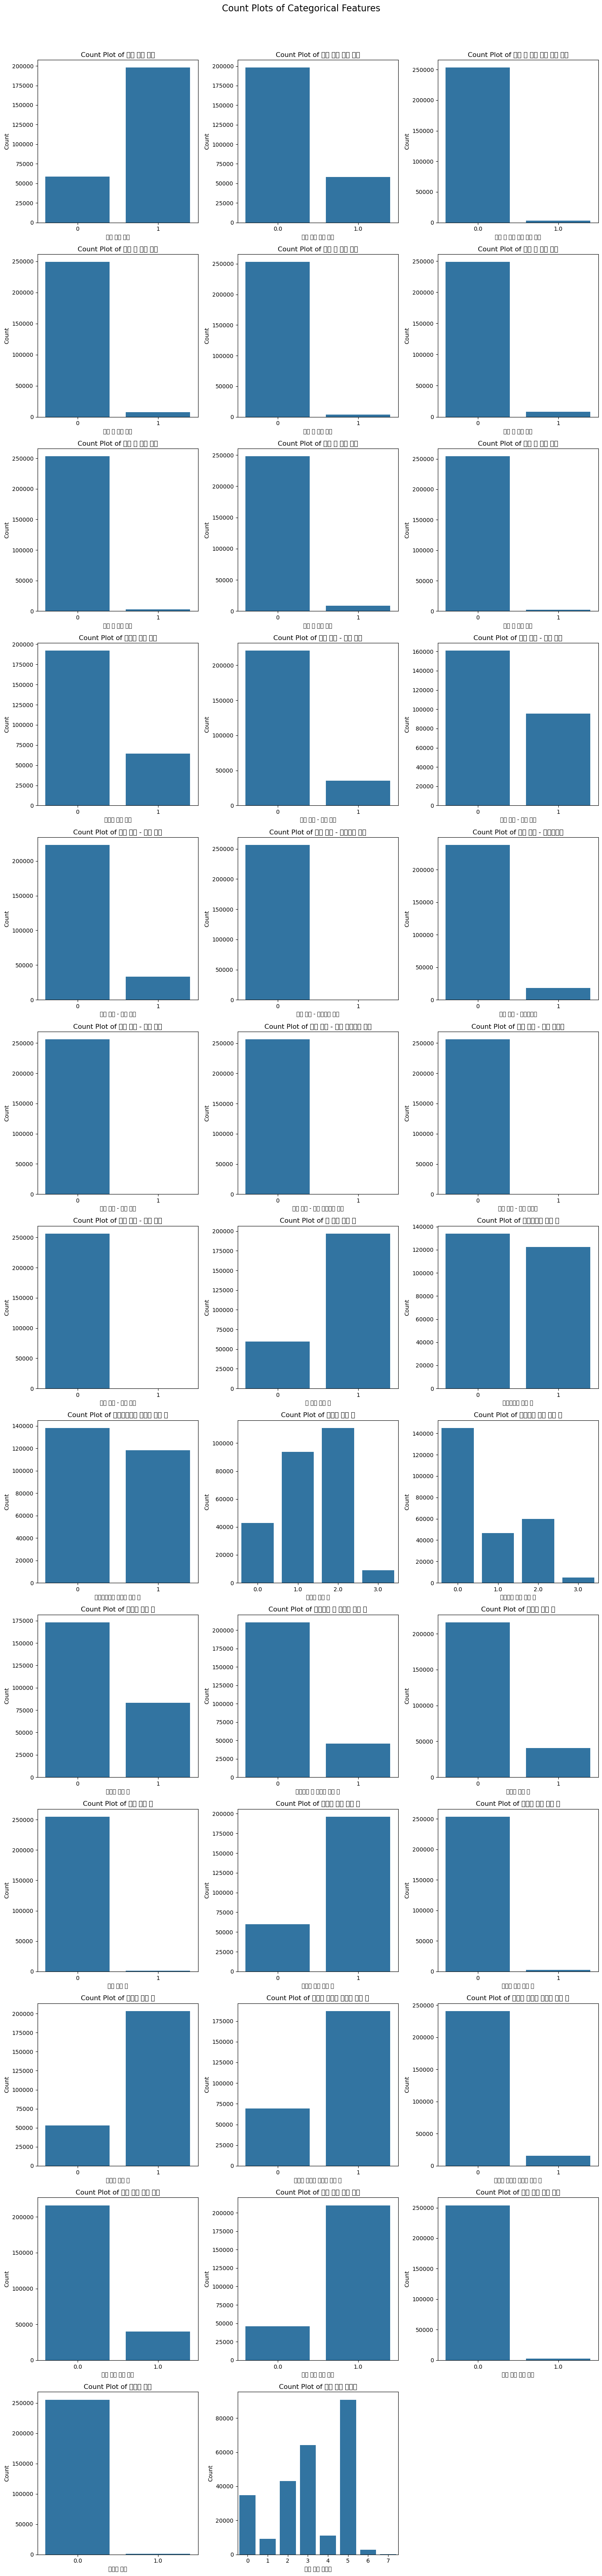

In [131]:
num_cols = len(numerical_cols)
num_rows = math.ceil(num_cols / 3)  # 예시: 3열로 배치, 필요에 따라 조정

# 전체 Figure 및 Subplots 생성
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5 * num_rows)) # figsize 조정

# 전체 Figure 제목 (옵션)
fig.suptitle('Count Plots of Categorical Features', fontsize=16)

# 각 subplot에 countplot 그리기
for i, col in enumerate(numerical_cols):
    ax = axes[i // 3, i % 3]  # 행, 열 인덱스 계산
    sns.countplot(data=binary_transformed_df, x=col, ax=ax) # ax 파라미터에 subplot 지정
    ax.set_title(f'Count Plot of {col}') # subplot 제목 설정 (옵션)
    ax.tick_params(axis='x', labelsize=10) # x축 레이블 설정 (옵션)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

# 빈 subplot 제거 및 레이아웃 조정
if num_cols < num_rows * 3: # subplot이 부족한 경우 빈 subplot 제거
    for j in range(num_cols, num_rows * 3):
        fig.delaxes(axes.flatten()[j]) # 빈 subplot 삭제

plt.tight_layout(rect=[0, 0, 1, 0.97]) # 전체 제목 위한 레이아웃 조정 (옵션)
plt.show()

d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46976 (\N{HANGUL SYLLABLE RAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\L

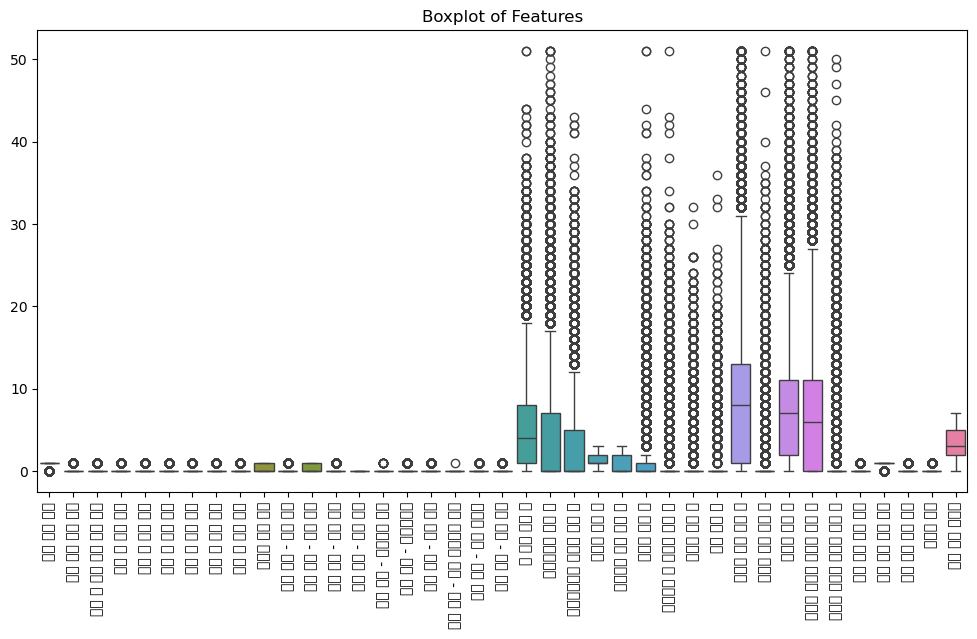

In [ ]:
# 2. 박스플롯 (Box Plot) - 이상치 탐색
plt.figure(figsize=(12, 6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.show()

## 이상치 제거

In [91]:
# # IQR 이상치 제거 함수
# def remove_outliers_iqr(df, columns):
#     for col in columns:
#         Q1 = df[col].quantile(0.25)  # 1사분위수 (25%)
#         Q3 = df[col].quantile(0.75)  # 3사분위수 (75%)
#         IQR = Q3 - Q1  # IQR 계산
#         lower_bound = Q1 - 1.5 * IQR  # 하한값
#         upper_bound = Q3 + 1.5 * IQR  # 상한값
        
#         # 이상치가 아닌 데이터만 남김 (이상치 제거)
#         df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
#     return df

# # 연속형 컬럼에 대해서만 IQR 이상치 제거 적용
# train_cleaned = remove_outliers_iqr(train_df, continuous_cols)
# test_cleaned = remove_outliers_iqr(test_df, continuous_cols)
# print("이상치 제거 후 데이터 크기:", train_cleaned.shape)

## 저장

In [132]:
binary_transformed_df['임신 성공 여부'] = y
binary_transformed_df.to_csv('train_out.csv', index=False, encoding='utf-8-sig')
binary_tt_df.to_csv('test_out.csv', index=False, encoding='utf-8-sig')